In [75]:
import pandas as pd
import numpy as np


def add_delta_columns(df: pd.DataFrame, methods=None) -> pd.DataFrame:
    """
    Add per-method delta columns:
    Delta = Unseen - Seen
    DeltaRatio currently mirrors Delta as in the original notebook logic.
    """
    if methods is None:
        methods = ["cade", "chen", "enidrift", "pe", "lmt"]

    df = df.copy()

    for m in methods:
        benign_col = f"{m}_score_benign"
        seen_col = f"{m}_score_seen_mean"
        unseen_col = f"{m}_score_unseen"
        delta_col = f"{m}_delta"
        deltaratio_col = f"{m}_deltaratio"

        if seen_col in df.columns and unseen_col in df.columns:
            df[delta_col] = df[unseen_col] - df[seen_col]
            df[deltaratio_col] = df[delta_col]
        else:
            df[delta_col] = np.nan
            df[deltaratio_col] = np.nan

    return df


def make_stage_label(row: pd.Series) -> str:
    """
    Convert seen_classes into a readable stage label.
    Example:
    'Benign | HTTP Flood | OS Scan' -> 'S2 = Benign + Attack(1..2)'
    """
    classes = [x.strip() for x in str(row["seen_classes"]).split("|")]
    if len(classes) <= 1:
        return "Baseline"

    attacks = [c for c in classes if c != "Benign"]
    if len(attacks) == 0:
        return "Baseline"

    return f"S{len(attacks)} = Benign + Attack(1..{len(attacks)})"


def add_stage_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add stage_label column.
    """
    df = df.copy()
    df["stage_label"] = df.apply(make_stage_label, axis=1)
    return df


def build_table_long(df: pd.DataFrame, methods=None, round_digits=2) -> pd.DataFrame:
    """
    Transform the wide experiment CSV into the long-format summary table.
    """
    if methods is None:
        methods = ["cade", "chen", "enidrift", "pe", "lmt"]

    rows = []

    for _, r in df.iterrows():
        for m in methods:
            rows.append({
                "Stage": r["stage_label"],
                "Stage_ID": r["stage_id"],
                "Probe": r["probe_class"],
                "Drift Method": m.upper(),
                "Acc": r["accuracy"],
                "F1": r["f1_macro"],
                "Benign": r.get(f"{m}_score_benign", np.nan),
                "Seen": r.get(f"{m}_score_seen_mean", np.nan),
                "Unseen": r.get(f"{m}_score_unseen", np.nan),
                "Delta": r.get(f"{m}_delta", np.nan),
            })

    table_long = pd.DataFrame(rows)

    num_cols = ["Acc", "F1", "Benign", "Seen", "Unseen", "Delta"]
    for col in num_cols:
        if col in table_long.columns:
            table_long[col] = table_long[col].round(round_digits)

    return table_long


def load_progressive_results(csv_path: str, methods=None, round_digits=2):
    """
    Full pipeline:
    1. load csv
    2. add delta columns
    3. add stage labels
    4. build long table

    Returns:
        df_raw, table_long
    """
    if methods is None:
        methods = ["cade", "chen", "enidrift", "pe", "lmt"]

    df = pd.read_csv(csv_path)
    df = add_delta_columns(df, methods=methods)
    df = add_stage_labels(df)
    table_long = build_table_long(df, methods=methods, round_digits=round_digits)

    return df, table_long

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_conditional_subplots(
    table_long: pd.DataFrame,
    save_path="ciciot23.pdf",
    method_order=None,
    figsize_per_plot=(5, 6),
    font_main=32,
    font_extra=30,
    show=True,
):
    """
    Plot 1 x N subplot of conditional drift scores (Benign, Seen, Unseen).

    Parameters
    ----------
    table_long : pd.DataFrame
        Must contain columns:
        Stage, Stage_ID, Probe, Drift Method, Benign, Seen, Unseen

    save_path : str
        Output figure path

    method_order : list or None
        Order of methods to display

    figsize_per_plot : tuple
        Size per subplot (width, height)

    font_main : int
        Main font size

    show : bool
        Whether to display the plot
    """

    # ---------------------------------------------------------
    # Style
    # ---------------------------------------------------------
    COLORS = {
        "dark_blue": "#34669A",
        "orange": "#E0795F",
        "red": "#B00A0B",
    }

    plt.rcParams["font.size"] = font_main
    plt.rcParams["axes.labelsize"] = font_main
    plt.rcParams["xtick.labelsize"] = font_main
    plt.rcParams["ytick.labelsize"] = font_main
    plt.rcParams["legend.fontsize"] = font_main

    # ---------------------------------------------------------
    # Clean data
    # ---------------------------------------------------------
    dfp = table_long.copy()

    dfp = dfp[dfp["Probe"].astype(str) != "None"].copy()
    dfp["Drift Method"] = dfp["Drift Method"].astype(str).str.upper()
    dfp = dfp.dropna(subset=["Benign", "Seen", "Unseen"])

    # method order
    if method_order is None:
        method_order = ["CADE", "CHEN", "ENIDRIFT", "PE", "LMT"]

    method_order = [m for m in method_order if m in dfp["Drift Method"].unique()]

    # stage order
    stage_order = (
        dfp[["Stage_ID", "Stage"]]
        .drop_duplicates()
        .sort_values("Stage_ID")
    )

    stage_ids = stage_order["Stage_ID"].tolist()

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    n_methods = len(method_order)
    fig_w = figsize_per_plot[0] * n_methods
    fig_h = figsize_per_plot[1]

    fig, axes = plt.subplots(1, n_methods, figsize=(fig_w, fig_h), sharex=True)

    if n_methods == 1:
        axes = [axes]

    for ax, method in zip(axes, method_order):
        sub = dfp[dfp["Drift Method"] == method].copy()
        sub = sub.sort_values("Stage_ID")

        sub = (
            pd.DataFrame({"Stage_ID": stage_ids})
            .merge(sub, on="Stage_ID", how="left")
        )

        x = np.arange(len(stage_ids))

        ax.plot(
            x, sub["Benign"].values,
            marker="o", linewidth=3, markersize=10,
            color=COLORS["dark_blue"], label="Benign"
        )
        ax.plot(
            x, sub["Seen"].values,
            marker="s", linewidth=3, markersize=10,
            color=COLORS["orange"], label="Seen"
        )
        ax.plot(
            x, sub["Unseen"].values,
            marker="^", linewidth=3, markersize=12,
            color=COLORS["red"], label="Unseen"
        )

        ax.set_title(method, fontsize=font_main)
        ax.set_xticks(x)
        ax.set_xticklabels([f"S{i+1}" for i in range(len(stage_ids))])
        ax.grid(alpha=0.25)

        if ax is axes[0]:
            ax.set_ylabel("Drift Score", fontsize=font_main)

    # shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

    fig.supxlabel("Stage", fontsize=font_main, y=0.2)

    plt.tight_layout(rect=[0, 0.05, 1, 0.9])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()

    return stage_order.reset_index(drop=True)

### Generate the Table

In [77]:
csv_path = "../data/public_datasets/res_android_mal/public_progressive_cae.csv"
methods = ["cade", "chen", "enidrift", "pe", "lmt"]

df, table_long = load_progressive_results(
    csv_path=csv_path,
    methods=methods,
    round_digits=2,
)

print(df[["stage_id", "seen_classes", "stage_label", "probe_class"]].head())
table_long.head(20)

   stage_id                                       seen_classes  \
0         1                                    benign | dowgin   
1         2                          benign | dowgin | fakeapp   
2         3           benign | dowgin | fakeapp | simplelocker   
3         4  benign | dowgin | fakeapp | simplelocker | pla...   
4         5  benign | dowgin | fakeapp | simplelocker | pla...   

                  stage_label   probe_class  
0  S2 = Benign + Attack(1..2)       fakeapp  
1  S3 = Benign + Attack(1..3)  simplelocker  
2  S4 = Benign + Attack(1..4)      plankton  
3  S5 = Benign + Attack(1..5)        svpeng  
4  S6 = Benign + Attack(1..6)         youmi  


,Stage,Stage_ID,Probe,Drift Method,Acc,F1,Benign,Seen,Unseen,Delta
0,S2 = Benign + Attack(1..2),1,fakeapp,CADE,0.62,0.46,0.69,0.59,0.66,0.07
1,S2 = Benign + Attack(1..2),1,fakeapp,CHEN,0.62,0.46,1.74,1.72,1.71,-0.01
2,S2 = Benign + Attack(1..2),1,fakeapp,ENIDRIFT,0.62,0.46,NaN,NaN,NaN,NaN
3,S2 = Benign + Attack(1..2),1,fakeapp,PE,0.62,0.46,0.38,0.46,0.54,0.09
4,S2 = Benign + Attack(1..2),1,fakeapp,LMT,0.62,0.46,9.78,13.30,13.48,0.18
5,S3 = Benign + Attack(1..3),2,simplelocker,CADE,0.49,0.41,0.96,0.91,1.10,0.19
6,S3 = Benign + Attack(1..3),2,simplelocker,CHEN,0.49,0.41,1.80,1.80,1.66,-0.14
7,S3 = Benign + Attack(1..3),2,simplelocker,ENIDRIFT,0.49,0.41,NaN,NaN,NaN,NaN
8,S3 = Benign + Attack(1..3),2,simplelocker,PE,0.49,0.41,0.57,0.77,0.88,0.11
9,S3 = Benign + Attack(1..3),2,simplelocker,LMT,0.49,0.41,13.20,17.36,20.15,2.79


### Generate the figure

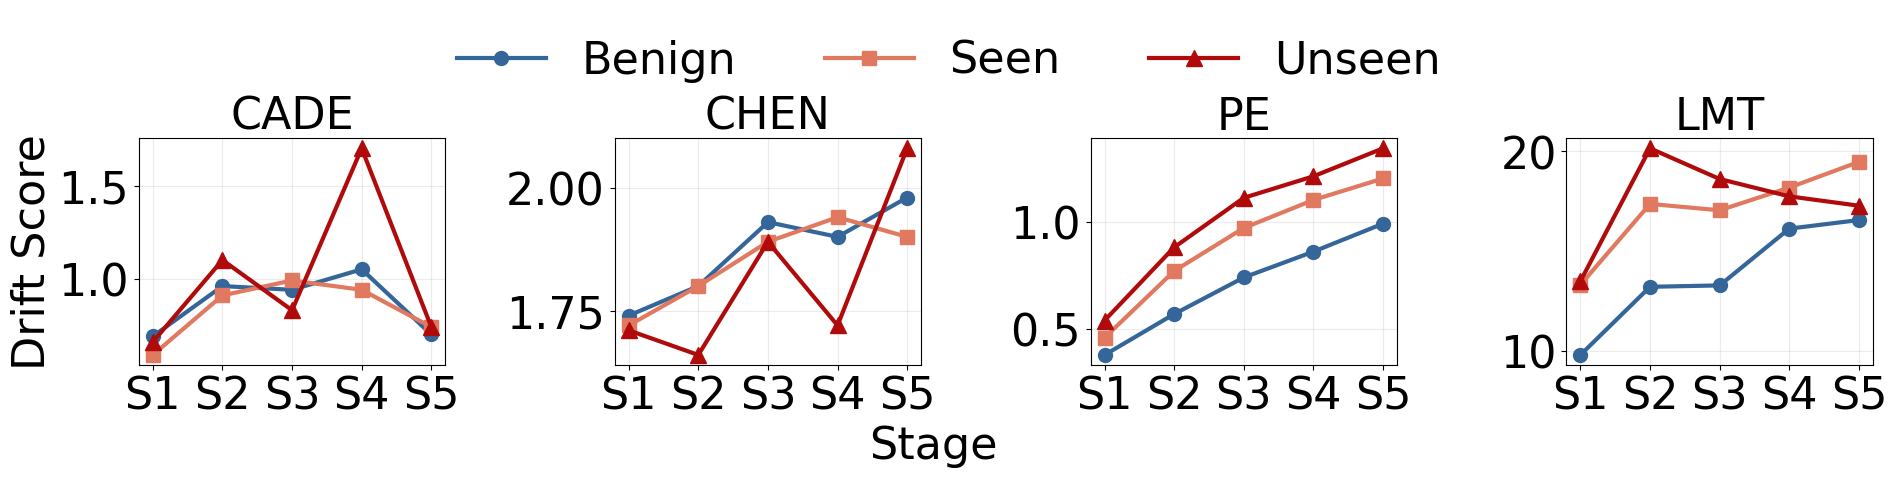

   Stage_ID                       Stage
0         1  S2 = Benign + Attack(1..2)
1         2  S3 = Benign + Attack(1..3)
2         3  S4 = Benign + Attack(1..4)
3         4  S5 = Benign + Attack(1..5)
4         5  S6 = Benign + Attack(1..6)


In [78]:
stage_map = plot_conditional_subplots(
    table_long,
    save_path="figs/android_mal.pdf",
)
print(stage_map)

## Kyoto 2006+

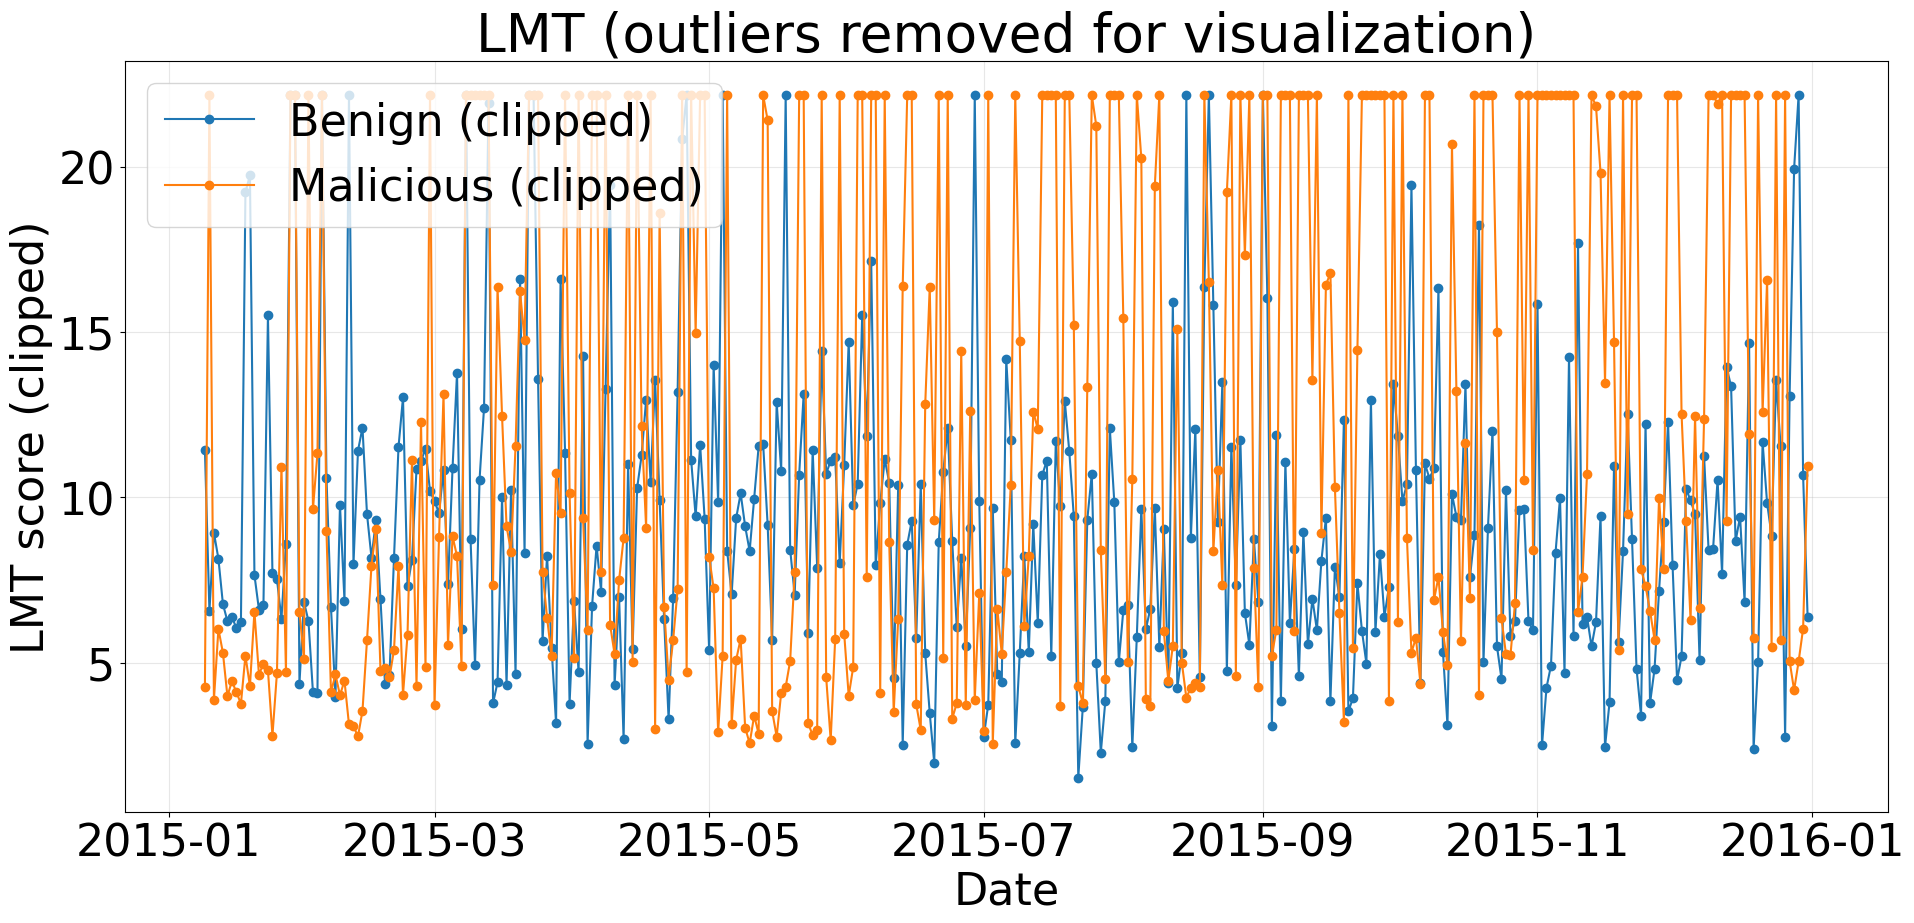

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("benign/kyoto_daily_scores_raw.csv")
df["block_start"] = pd.to_datetime(df["block_start"])

# compute cap from benign distribution
cap = df["lmt_score_benign"].quantile(0.96)

# clip both curves
df["lmt_ben_clip"] = df["lmt_score_benign"].clip(upper=cap)
df["lmt_mal_clip"] = df["lmt_score_malicious"].clip(upper=cap)

plt.figure(figsize=(20, 10))

plt.plot(df["block_start"], df["lmt_ben_clip"], label="Benign (clipped)", marker="o")
plt.plot(df["block_start"], df["lmt_mal_clip"], label="Malicious (clipped)", marker="o")

plt.xlabel("Date")
plt.ylabel("LMT score (clipped)")
plt.title("LMT (outliers removed for visualization)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

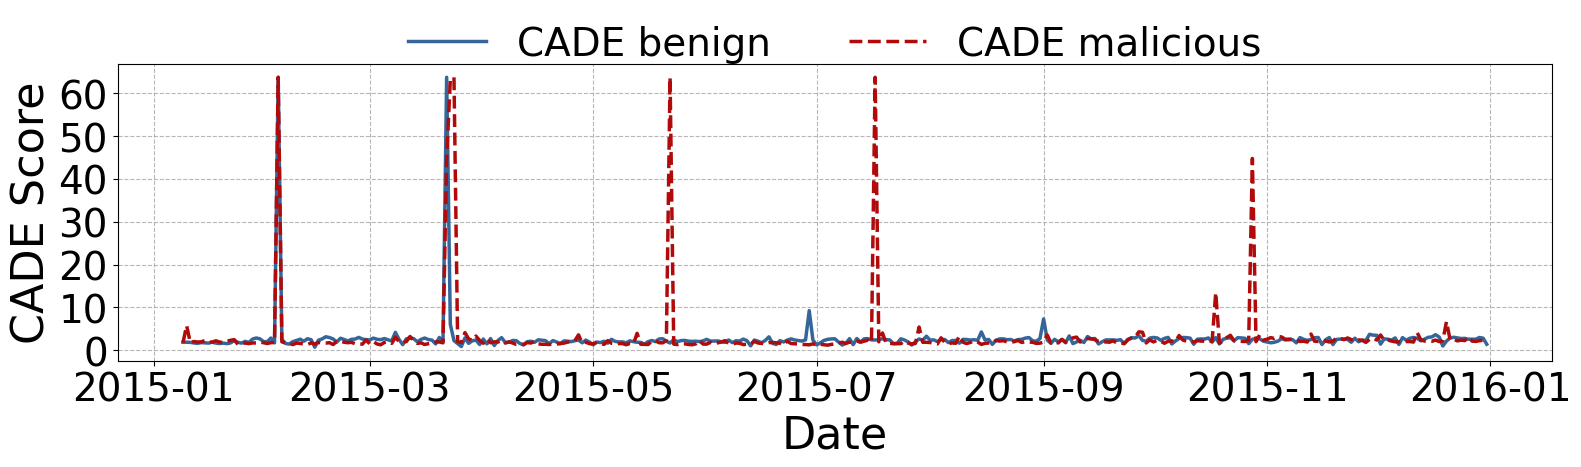

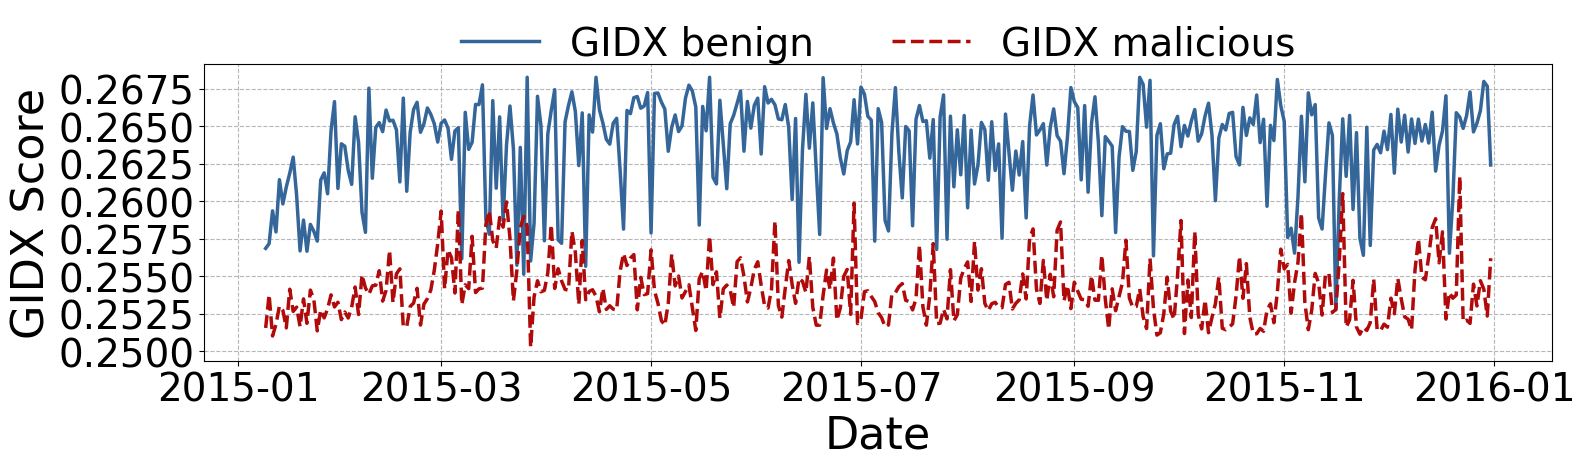

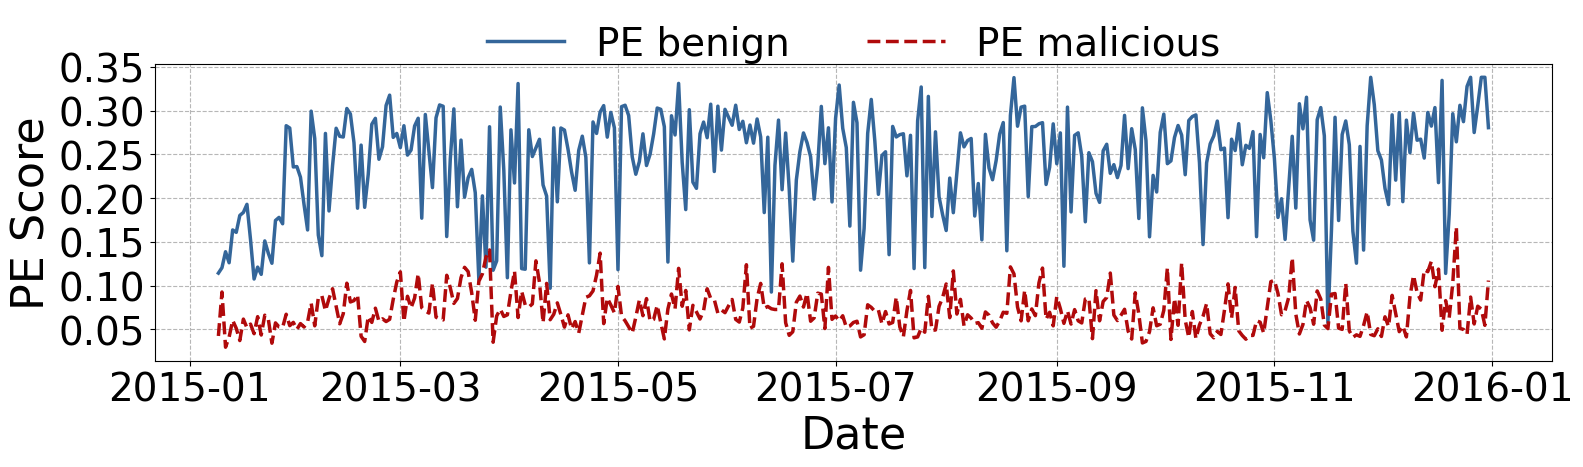

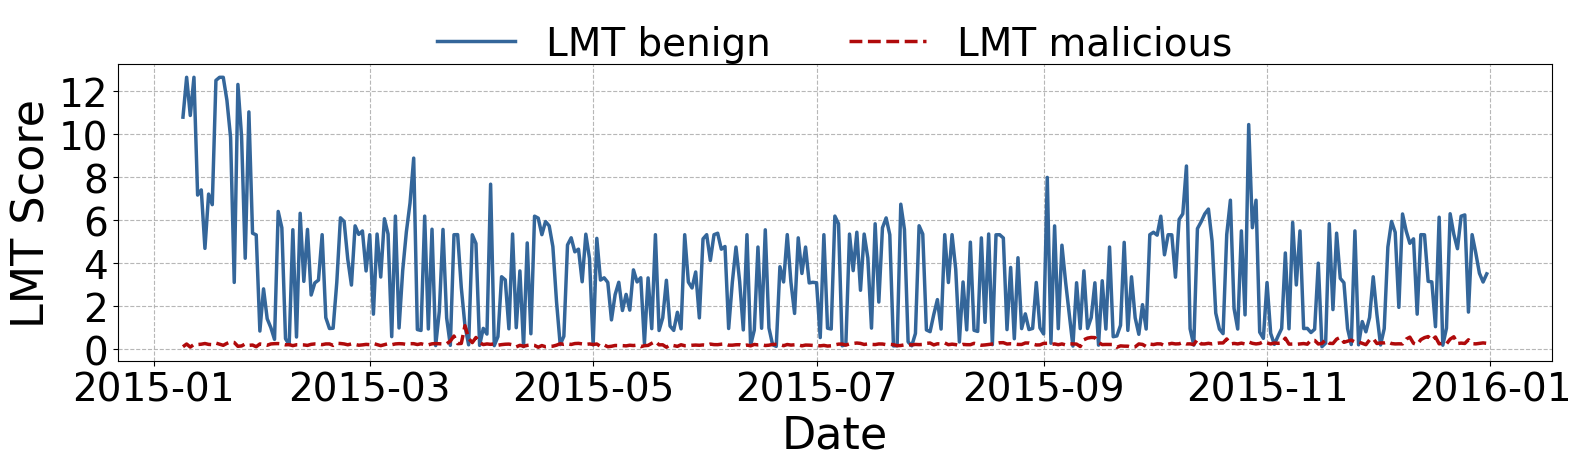

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# === Load ===
df = pd.read_csv("kyoto/kyoto_daily_scores.csv")
df["block_start"] = pd.to_datetime(df["block_start"])

# === Style settings ===
font_main = 32
font_extra = 28
figsize = (16, 5)

color_benign = "#34669A"
color_malicious = "#B00A0B"

indicators = ["cade", "gidx", "pe", "lmt"]

for ind in indicators:
    ben_col = f"{ind}_score_benign"
    mal_col = f"{ind}_score_malicious"

    # === robust clipping (avoid spike domination) ===
    cap = max(
        df[ben_col].quantile(0.99),
        df[mal_col].quantile(0.99),
    )

    ben_plot = df[ben_col].clip(upper=cap)
    mal_plot = df[mal_col].clip(upper=cap)

    plt.figure(figsize=figsize)

    plt.plot(
        df["block_start"],
        ben_plot,
        color=color_benign,
        linewidth=2.5,
        #marker="o",
        label=f"{ind.upper()} benign"
    )

    plt.plot(
        df["block_start"],
        mal_plot,
        color=color_malicious,
        linewidth=2.5,
        linestyle="--",
        #marker="o",
        label=f"{ind.upper()} malicious"
    )

    # === Labels ===
    plt.ylabel(f"{ind.upper()} Score", fontsize=font_main)
    plt.xlabel("Date", fontsize=font_main)

    # === Grid ===
    plt.grid(alpha=0.9, linestyle="--")

    # === Legend ===
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.25),
        ncol=2,
        frameon=False,
        fontsize=font_extra
    )

    # === Axis formatting ===
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.xticks(rotation=0, fontsize=font_extra)
    plt.yticks(fontsize=font_extra)

    plt.tight_layout()

    # === Save ===
    plt.savefig(
        f"kyoto_{ind}_benign_vs_malicious.pdf",
        bbox_inches="tight"
    )

    plt.show()

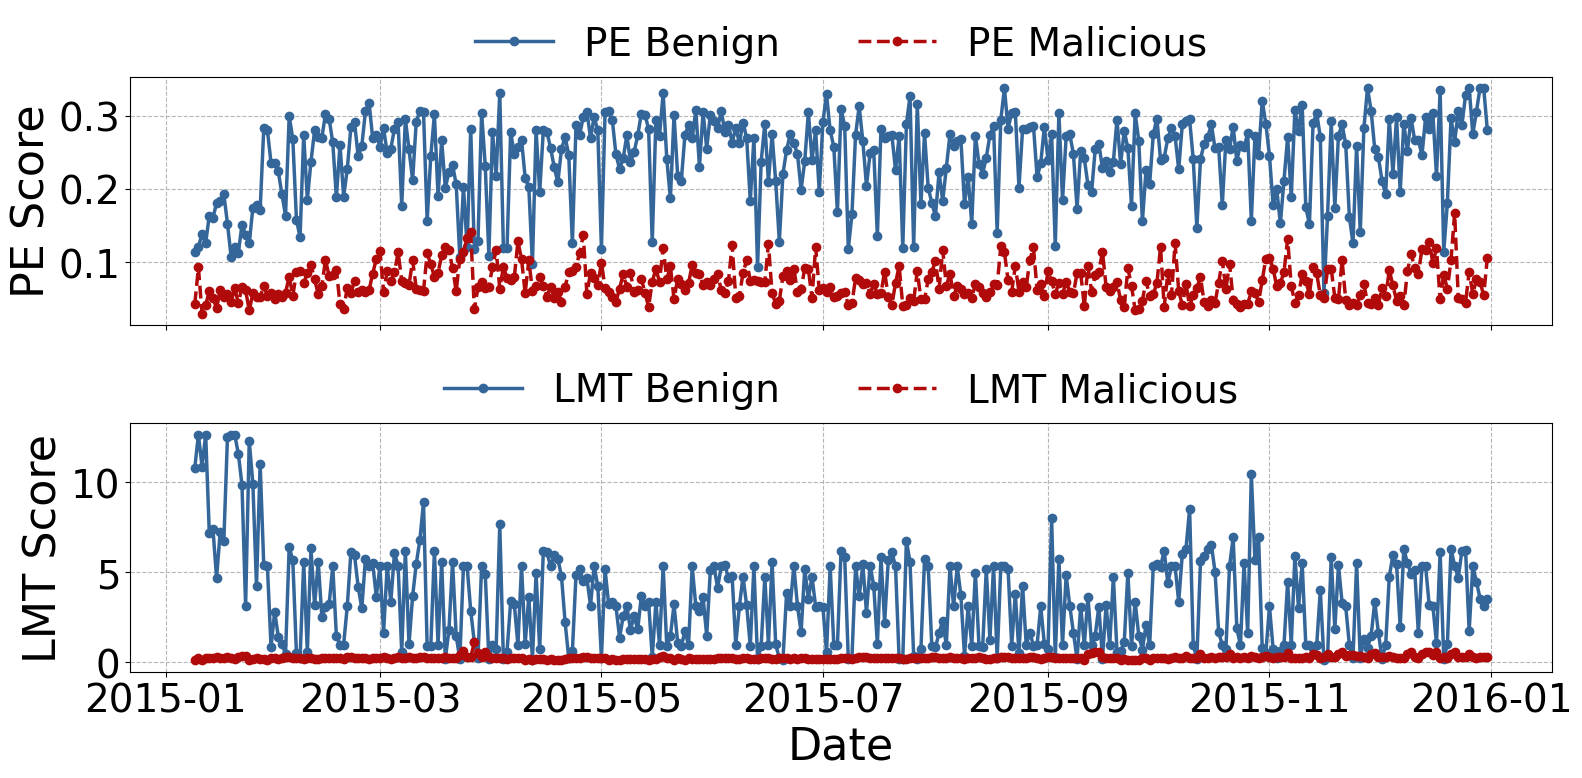

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# === Load ===
df = pd.read_csv("kyoto/kyoto_daily_scores.csv")
df["block_start"] = pd.to_datetime(df["block_start"])

# === Style settings ===
font_main = 32
font_extra = 28
figsize = (16, 8)

color_benign = "#34669A"
color_malicious = "#B00A0B"

# === Figure with shared x-axis ===
fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

# =========================================================
# 1. PE
# =========================================================
cap_pe = max(
    df["pe_score_benign"].quantile(0.99),
    df["pe_score_malicious"].quantile(0.99),
)

pe_b = df["pe_score_benign"].clip(upper=cap_pe)
pe_m = df["pe_score_malicious"].clip(upper=cap_pe)

axes[0].plot(
    df["block_start"],
    pe_b,
    color=color_benign,
    linewidth=2.5,
    marker="o",
    label="PE Benign"
)

axes[0].plot(
    df["block_start"],
    pe_m,
    color=color_malicious,
    linewidth=2.5,
    linestyle="--",
    marker="o",
    label="PE Malicious"
)

axes[0].set_ylabel("PE Score", fontsize=font_main)
#axes[0].set_title("PE: benign vs malicious", fontsize=font_main)

axes[0].grid(alpha=0.9, linestyle="--")

axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.35),
    ncol=2,
    frameon=False,
    fontsize=font_extra
)

# =========================================================
# 2. LMT
# =========================================================
cap_lmt = max(
    df["lmt_score_benign"].quantile(0.99),
    df["lmt_score_malicious"].quantile(0.99),
)

lmt_b = df["lmt_score_benign"].clip(upper=cap_lmt)
lmt_m = df["lmt_score_malicious"].clip(upper=cap_lmt)

axes[1].plot(
    df["block_start"],
    lmt_b,
    color=color_benign,
    linewidth=2.5,
    marker="o",
    label="LMT Benign"
)

axes[1].plot(
    df["block_start"],
    lmt_m,
    color=color_malicious,
    linewidth=2.5,
    linestyle="--",
    marker="o",
    label="LMT Malicious"
)

axes[1].set_ylabel("LMT Score", fontsize=font_main)
#axes[1].set_title("LMT: benign vs malicious", fontsize=font_main)

axes[1].grid(alpha=0.9, linestyle="--")

axes[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.35),
    ncol=2,
    frameon=False,
    fontsize=font_extra
)

# =========================================================
# Shared X-axis formatting
# =========================================================
axes[1].set_xlabel("Date", fontsize=font_main)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=0, fontsize=font_extra)
axes[0].tick_params(axis='y', labelsize=font_extra)
axes[1].tick_params(axis='y', labelsize=font_extra)

plt.tight_layout()

# === Save ===
plt.savefig(
    "kyoto_evaluation.pdf",
    bbox_inches="tight"
)

plt.show()

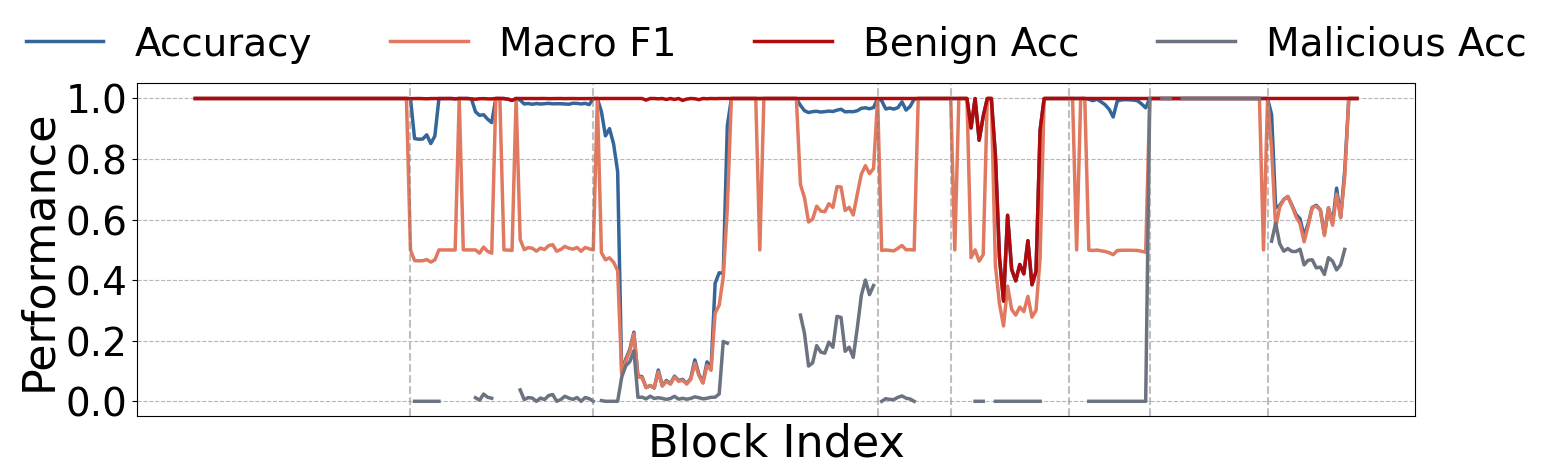

IDS17 Chronological Stream Performance


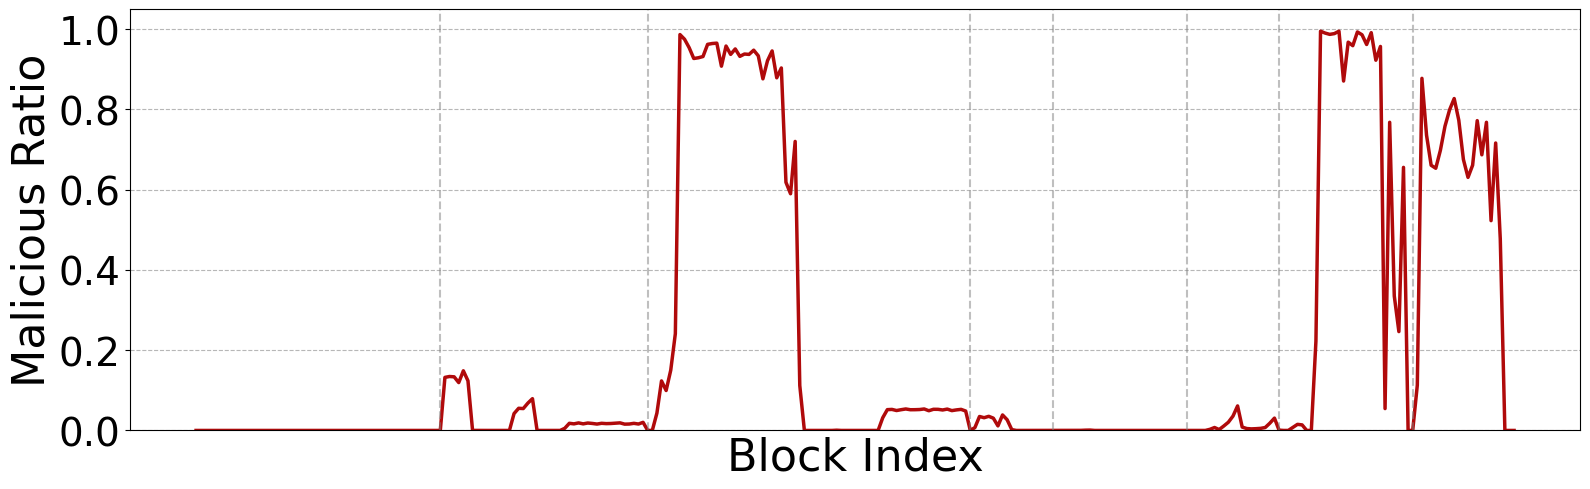

Malicious Proportion Over the Stream


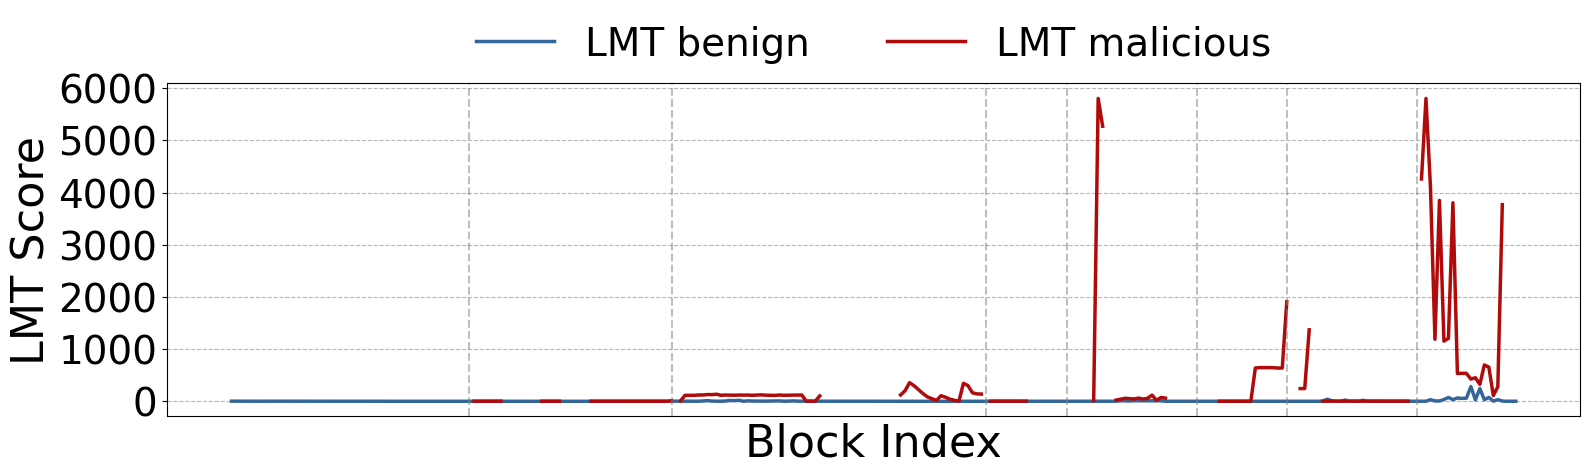

LMT: Benign vs Malicious


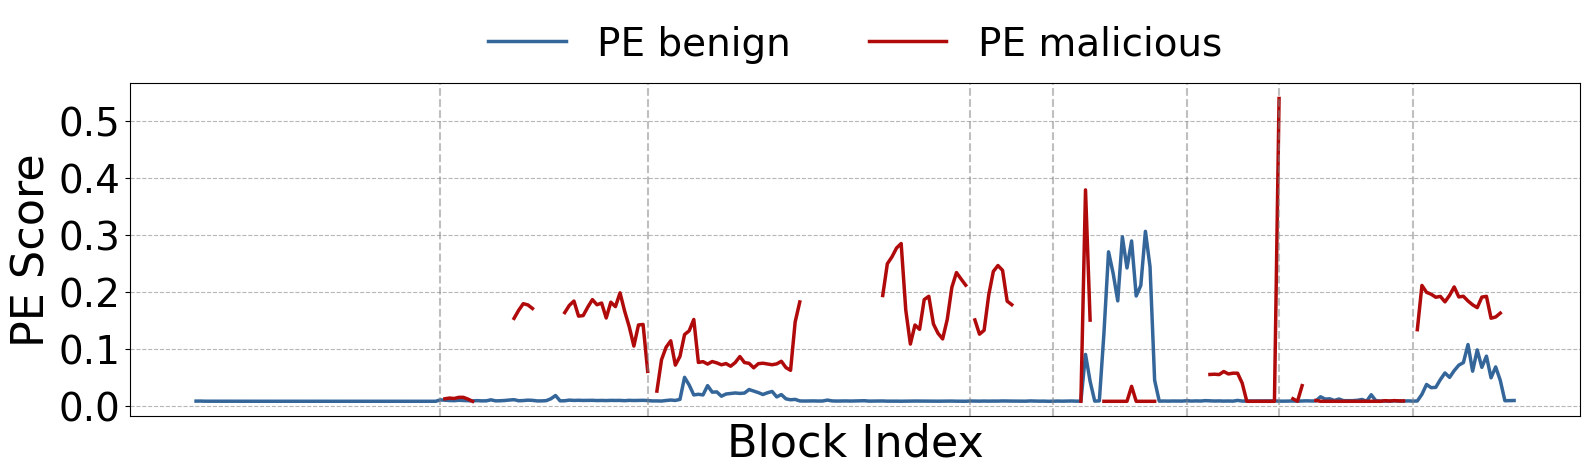

PE: Benign vs Malicious


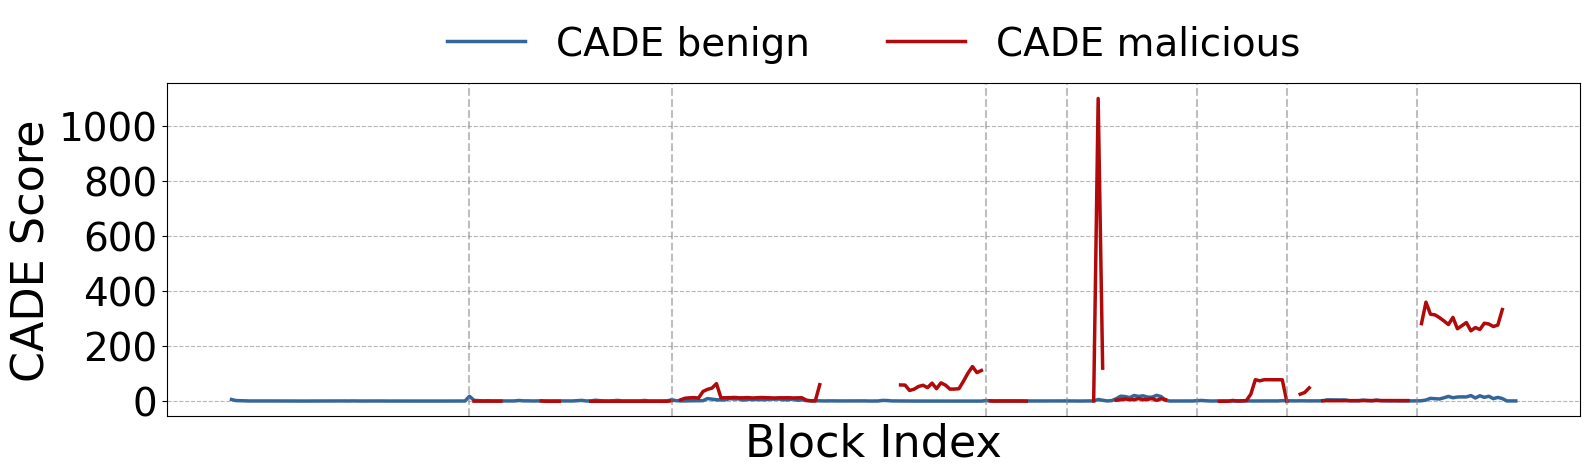

CADE: Benign vs Malicious


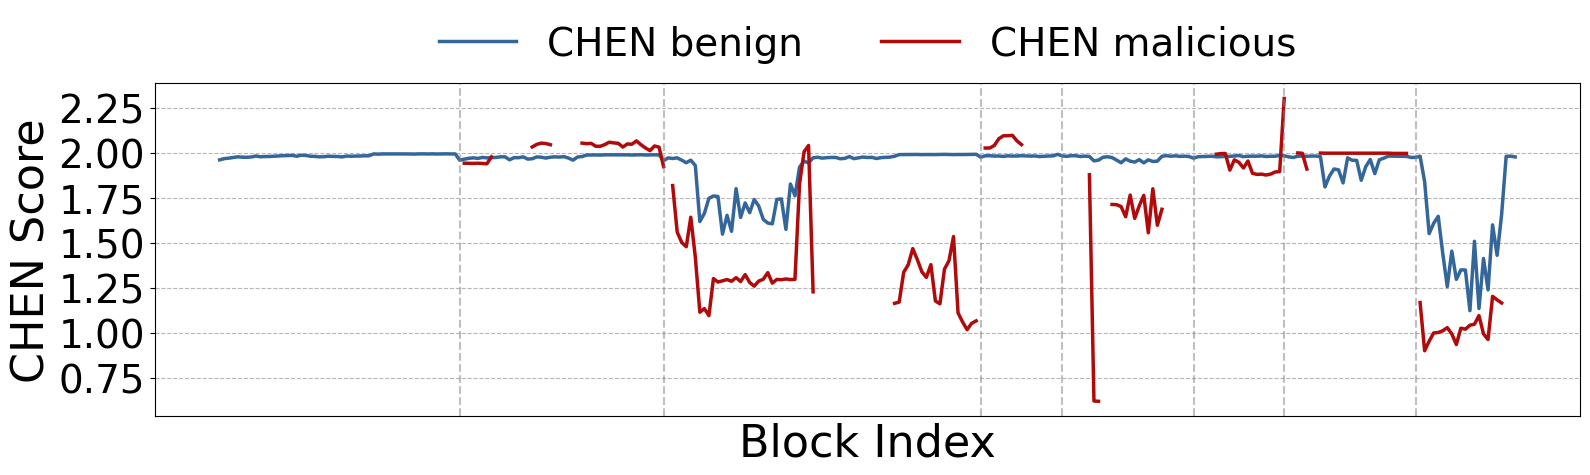

CHEN: Benign vs Malicious


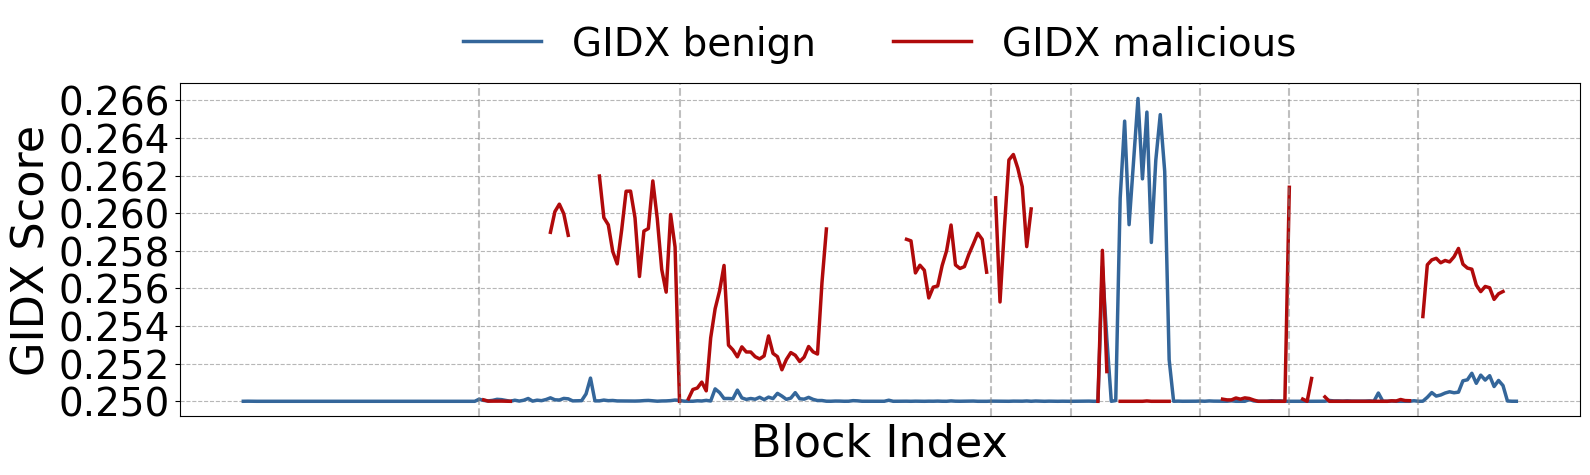

GIDX: Benign vs Malicious


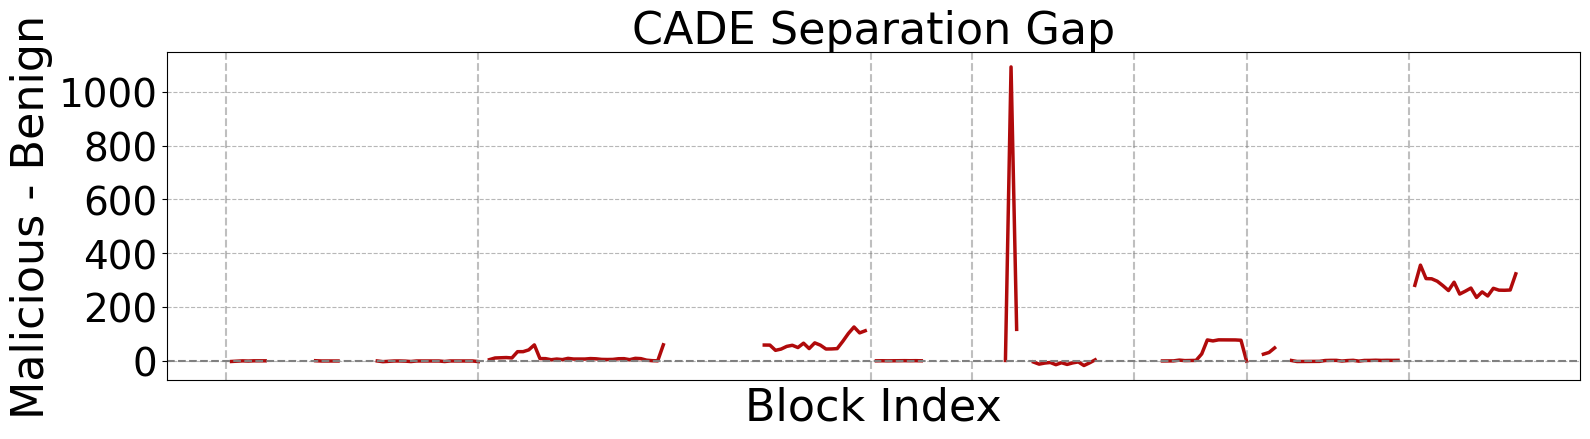

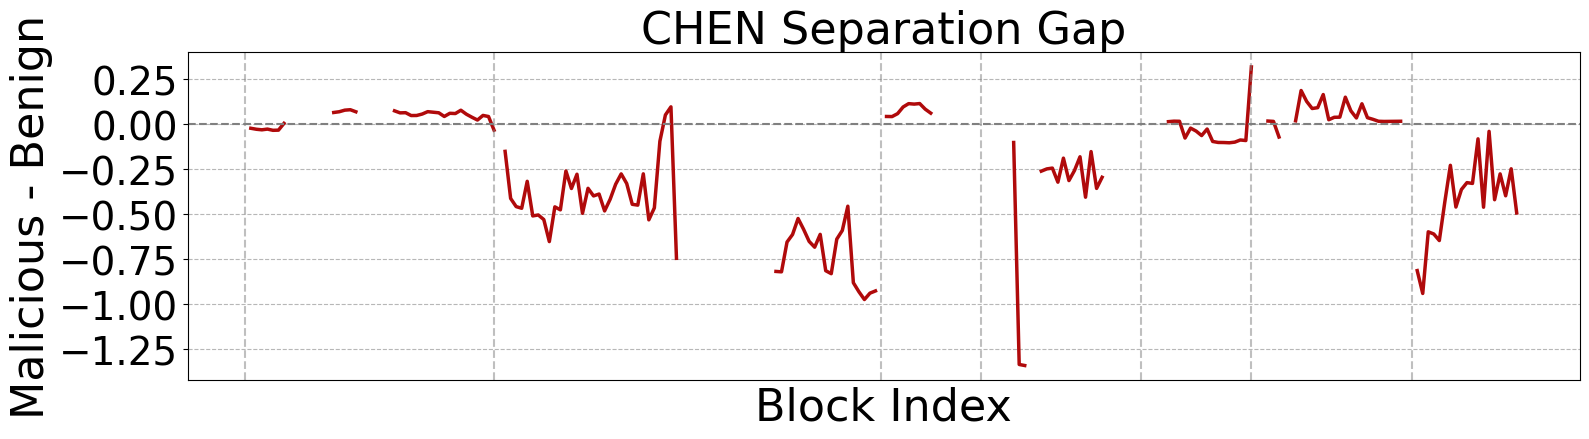

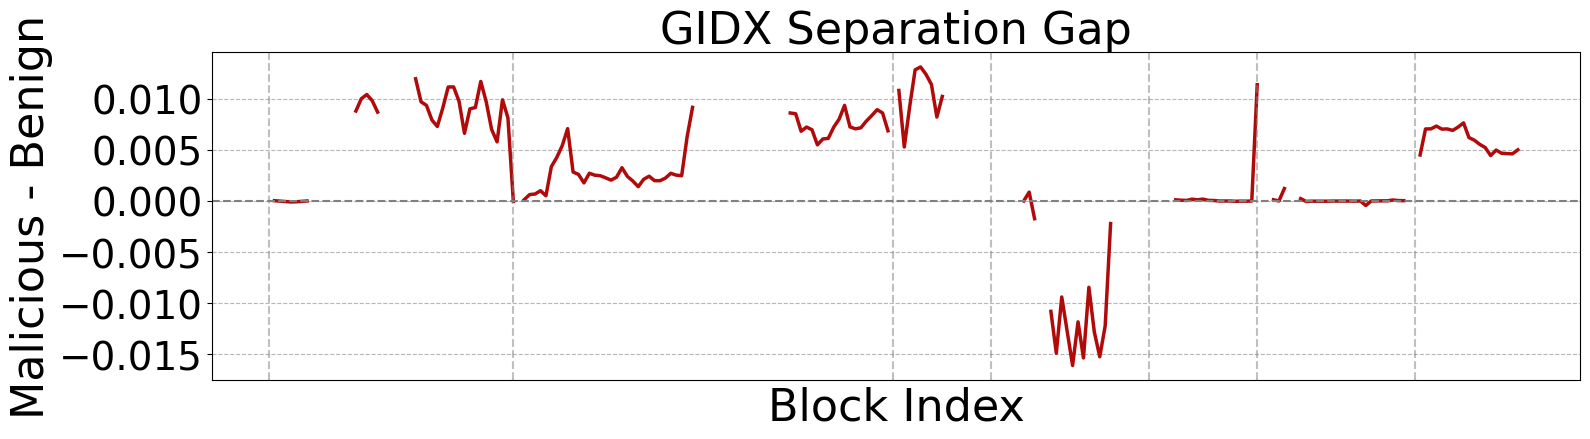

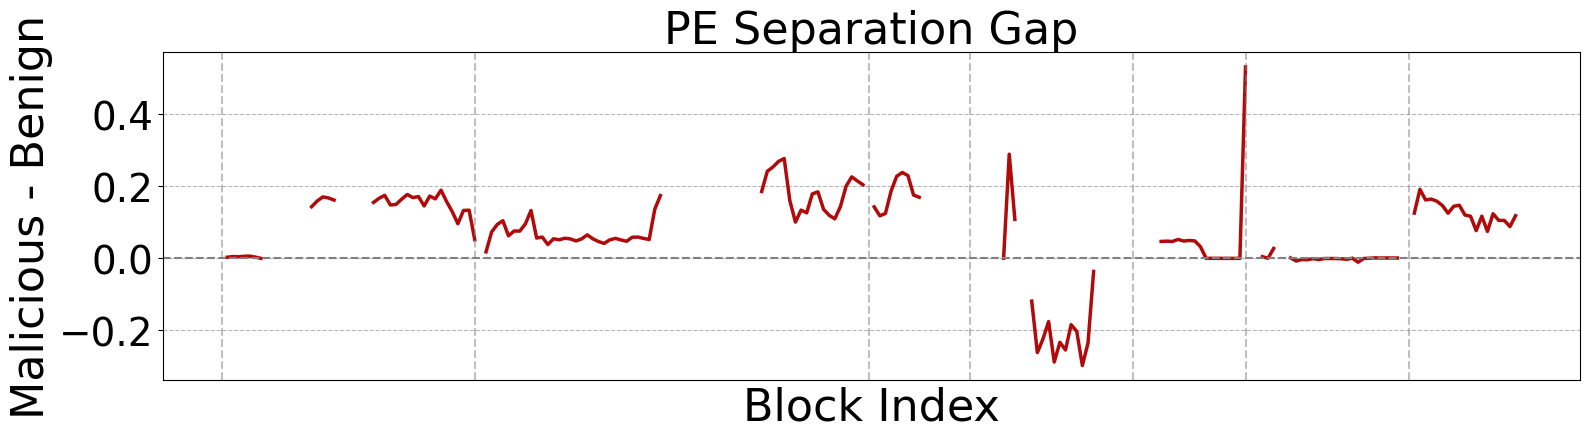

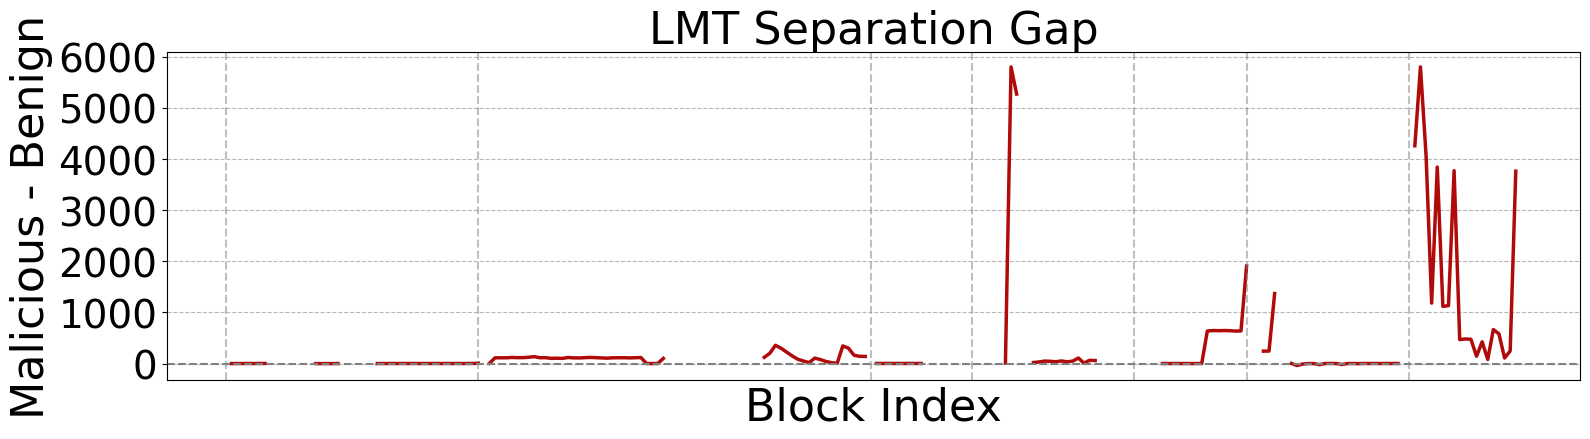

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_PATH = "ids17/ids17_portscan_stream_scores.csv"

# === Style settings ===
FIG_SIZE = (16, 5)
font_main = 32
font_extra = 28

color_benign = "#34669A"
color_malicious = "#B00A0B"
color_perf1 = "#34669A"
color_perf2 = "#E0795F"
color_perf3 = "#B00A0B"
color_perf4 = "#6B7280"

df = pd.read_csv(CSV_PATH)
df = df.sort_values("global_block_id").reset_index(drop=True)

x = np.arange(len(df))

# -----------------------------
# Helpers
# -----------------------------
def add_day_boundaries(dataframe):
    for i in range(1, len(dataframe)):
        if dataframe["file_order"].iloc[i] != dataframe["file_order"].iloc[i - 1]:
            plt.axvline(
                x=i,
                color="gray",
                linestyle="--",
                alpha=0.5,
                linewidth=1.5
            )

def apply_common_style(ylabel, xlabel="Block Index", title=None, legend=True, ylim=None):
    plt.ylabel(ylabel, fontsize=font_main)
    plt.xlabel(xlabel, fontsize=font_main)

    if title is not None:
        plt.title(title, fontsize=font_main)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.grid(alpha=0.9, linestyle="--")
    plt.xticks([], fontsize=font_extra)
    plt.yticks(fontsize=font_extra)

    if legend:
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, 1.28),
            ncol=4,
            frameon=False,
            fontsize=font_extra
        )

    plt.tight_layout()

# -----------------------------
# 1. Performance
# -----------------------------
plt.figure(figsize=FIG_SIZE)

plt.plot(
    x, df["accuracy"],
    color=color_perf1,
    linewidth=2.5,
    label="Accuracy"
)
plt.plot(
    x, df["f1_macro"],
    color=color_perf2,
    linewidth=2.5,
    label="Macro F1"
)
plt.plot(
    x, df["acc_benign"],
    color=color_perf3,
    linewidth=2.5,
    label="Benign Acc"
)
plt.plot(
    x, df["acc_malicious"],
    color=color_perf4,
    linewidth=2.5,
    label="Malicious Acc"
)

add_day_boundaries(df)
apply_common_style(
    ylabel="Performance",
    xlabel="Block Index",
    #title="IDS17 Chronological Stream Performance",
    legend=True
)
plt.show()
print("IDS17 Chronological Stream Performance")

# -----------------------------
# 2. Malicious ratio
# -----------------------------
plt.figure(figsize=FIG_SIZE)

plt.plot(
    x, df["malicious_ratio"],
    color=color_malicious,
    linewidth=2.5
)

add_day_boundaries(df)
apply_common_style(
    ylabel="Malicious Ratio",
    xlabel="Block Index",
    #title="Malicious Proportion Over the Stream",
    legend=False,
    ylim=(0, 1.05)
)
plt.show()
print("Malicious Proportion Over the Stream")

# -----------------------------
# 3. LMT
# -----------------------------
plt.figure(figsize=FIG_SIZE)

lmt_cap = df["lmt_score_malicious"].quantile(0.99)
lmt_benign_plot = df["lmt_score_benign"].clip(upper=lmt_cap)
lmt_malicious_plot = df["lmt_score_malicious"].clip(upper=lmt_cap)

plt.plot(
    x, lmt_benign_plot,
    color=color_benign,
    linewidth=2.5,
    label="LMT benign"
)
plt.plot(
    x, lmt_malicious_plot,
    color=color_malicious,
    linewidth=2.5,
    label="LMT malicious"
)

add_day_boundaries(df)
apply_common_style(
    ylabel="LMT Score",
    xlabel="Block Index",
    #title="LMT: Benign vs Malicious",
    legend=True
)
plt.show()
print("LMT: Benign vs Malicious")

# -----------------------------
# 4. PE
# -----------------------------
plt.figure(figsize=FIG_SIZE)

plt.plot(
    x, df["pe_score_benign"],
    color=color_benign,
    linewidth=2.5,
    label="PE benign"
)
plt.plot(
    x, df["pe_score_malicious"],
    color=color_malicious,
    linewidth=2.5,
    label="PE malicious"
)

add_day_boundaries(df)
apply_common_style(
    ylabel="PE Score",
    xlabel="Block Index",
    #title="PE: Benign vs Malicious",
    legend=True
)
plt.show()
print("PE: Benign vs Malicious")

# -----------------------------
# 5. CADE
# -----------------------------
plt.figure(figsize=FIG_SIZE)

plt.plot(
    x, df["cade_score_benign"],
    color=color_benign,
    linewidth=2.5,
    label="CADE benign"
)
plt.plot(
    x, df["cade_score_malicious"],
    color=color_malicious,
    linewidth=2.5,
    label="CADE malicious"
)

add_day_boundaries(df)
apply_common_style(
    ylabel="CADE Score",
    xlabel="Block Index",
    #title="CADE: Benign vs Malicious",
    legend=True
)
plt.show()
print("CADE: Benign vs Malicious")

# -----------------------------
# 6. CHEN
# -----------------------------
plt.figure(figsize=FIG_SIZE)

plt.plot(
    x, df["chen_score_benign"],
    color=color_benign,
    linewidth=2.5,
    label="CHEN benign"
)
plt.plot(
    x, df["chen_score_malicious"],
    color=color_malicious,
    linewidth=2.5,
    label="CHEN malicious"
)

add_day_boundaries(df)
apply_common_style(
    ylabel="CHEN Score",
    xlabel="Block Index",
    #title="CHEN: Benign vs Malicious",
    legend=True
)
plt.show()
print("CHEN: Benign vs Malicious")

# -----------------------------
# 7. GIDX
# -----------------------------
plt.figure(figsize=FIG_SIZE)

plt.plot(
    x, df["gidx_score_benign"],
    color=color_benign,
    linewidth=2.5,
    label="GIDX benign"
)
plt.plot(
    x, df["gidx_score_malicious"],
    color=color_malicious,
    linewidth=2.5,
    label="GIDX malicious"
)

add_day_boundaries(df)
apply_common_style(
    ylabel="GIDX Score",
    xlabel="Block Index",
    #title="GIDX: Benign vs Malicious",
    legend=True
)
plt.show()
print("GIDX: Benign vs Malicious")

# -----------------------------
# 8. Separation gap
# -----------------------------
for method in ["cade", "chen", "gidx", "pe", "lmt"]:
    gap_col = f"{method}_gap"
    df[gap_col] = df[f"{method}_score_malicious"] - df[f"{method}_score_benign"]

    plt.figure(figsize=(16, 4.5))

    gap_plot = df[gap_col].copy()

    if method == "lmt":
        gap_cap = gap_plot.quantile(0.99)
        gap_plot = gap_plot.clip(upper=gap_cap)

    plt.plot(
        x, gap_plot,
        color=color_malicious,
        linewidth=2.5
    )
    plt.axhline(0, color="gray", linestyle="--", linewidth=1.5)

    add_day_boundaries(df)
    apply_common_style(
        ylabel="Malicious - Benign",
        xlabel="Block Index",
        title=f"{method.upper()} Separation Gap",
        legend=False
    )
    plt.show()

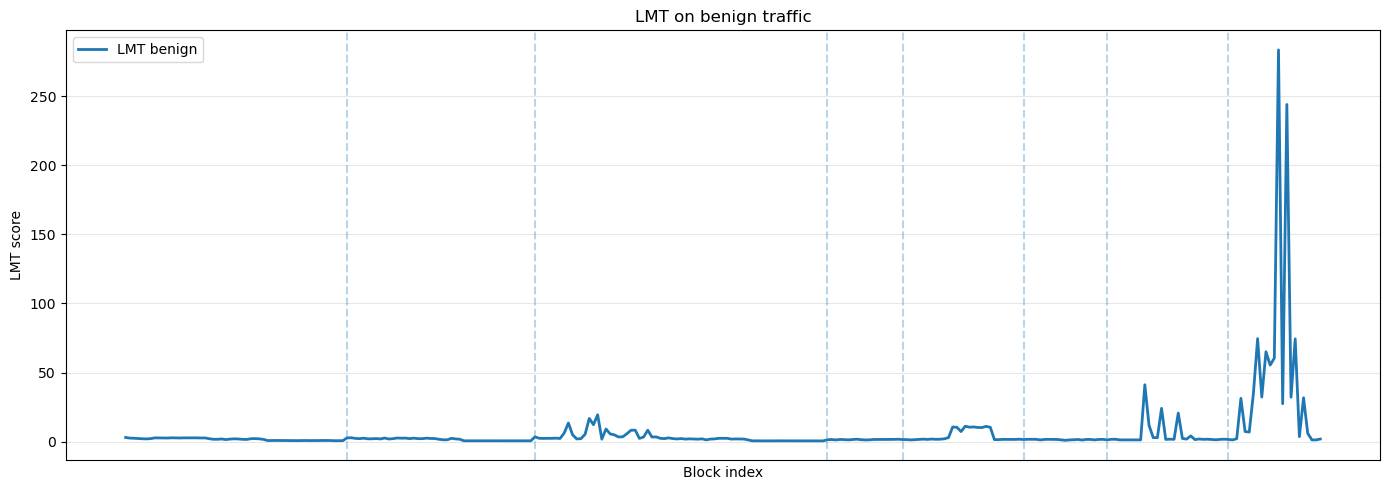

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ids17/ids17_portscan_stream_scores.csv")
df = df.sort_values("global_block_id").reset_index(drop=True)

x = np.arange(len(df))


def add_day_boundaries(df):
    for i in range(1, len(df)):
        if df["file_order"].iloc[i] != df["file_order"].iloc[i - 1]:
            plt.axvline(i, linestyle="--", alpha=0.3)


plt.figure(figsize=(14, 5))

plt.plot(x, df["lmt_score_benign"], linewidth=2, label="LMT benign")

plt.xticks([])
add_day_boundaries(df)

plt.ylabel("LMT score")
plt.xlabel("Block index")
plt.title("LMT on benign traffic")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()